# Reviewer-response simulations: tuning parameters, loss functions, and SCPI interval comparisons

This notebook adds simulation studies requested in the second-round referee report.

It covers three items:

1. **Practical selection of $h$ and $G$** using a pseudo-treatment validation rule.
2. **Loss-function comparison** between the current diagonal quadratic criterion and alternatives based on stacked moments.
3. **Simulation-based comparison with SCPI** for uncertainty quantification.

## Notes

- The original simulation notebooks are left intact, except that the Figure 2–3 notebook now includes SCPI point-estimator comparisons inside the existing simulation loop.
- The data-generating process below follows the structure used in the existing simulation notebooks.
- The SCPI sections require `scpi-pkg` to be installed.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

import warnings
warnings.filterwarnings('ignore')


In [12]:
try:
    from scpi_pkg.scdata import scdata
    from scpi_pkg.scest import scest
    from scpi_pkg.scpi import scpi
    SCPI_AVAILABLE = True
except ImportError:
    SCPI_AVAILABLE = False
    print("scpi_pkg is not available. Install it with `pip install scpi-pkg` to run the SCPI sections.")


In [13]:
def simulate_panel(
    num_untreatment_units,
    total_period=1050,
    intervention=50,
    dim=5,
    max_sample_size=1,
    treatment_effect=20,
    drop_unit="2",
):
    means = np.random.normal(size=(num_untreatment_units, dim))
    variances = np.random.uniform(1, 20, size=(num_untreatment_units, dim))
    params = np.random.uniform(0, 1, size=(num_untreatment_units, 1))
    params = params / np.sum(params)

    sample_sizes = np.array(
        np.random.uniform(1, max_sample_size, size=(num_untreatment_units + 1, total_period)),
        np.int64,
    )

    count = 0
    data = []

    for t in range(total_period):
        for i in range(-1, num_untreatment_units):
            temp_data = []

            if i == -1:
                temp_data2 = []
                for s in range(sample_sizes[i, t]):
                    if (t + 1) > intervention:
                        choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                        temp = (np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0]
                        temp[0] = temp[0] + treatment_effect
                        temp_data2.append(temp)
                    else:
                        choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                        temp_data2.append((np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0])
                temp_data = np.array(temp_data2)[0]
            else:
                temp_data = (np.random.multivariate_normal(means[i], np.diag(variances[i]), size=sample_sizes[i, t]))[0]

            temp_data = [t + 1, "%d" % i] + list(temp_data)
            if count == 0:
                data = pd.DataFrame(temp_data).T
                count += 1
            else:
                data_temp = pd.DataFrame(temp_data).T
                data = pd.concat([data, data_temp])

            means[:, 0] += np.random.normal(0, 10, size=means.shape[0])
            variances[:, 0] += np.random.normal(0, 10, size=variances.shape[0])
            variances[variances < 0.1] = 0.1

    data = data[data[1] != drop_unit]
    return data


def treatment_effect_path(model, target_year):
    treatment_effect_list = []
    for effect_year in range(1, (model.year[-1] - target_year) + 1):
        treatment_effect_temp, _, _ = model.treatment_effect(effect_year)
        treatment_effect_list.append(treatment_effect_temp)
    return np.array(treatment_effect_list, dtype=float).reshape(-1)


def mean_effect_error(model, true_treatment_effect, target_year):
    effect_path = treatment_effect_path(model, target_year)
    return np.mean(true_treatment_effect - effect_path)


def mse_effect_error(model, true_treatment_effect, target_year):
    effect_path = treatment_effect_path(model, target_year)
    return np.mean((true_treatment_effect - effect_path) ** 2)


def sanitize_bounds(lower, upper):
    lower = np.array(lower, dtype=float).reshape(-1)
    upper = np.array(upper, dtype=float).reshape(-1)
    return np.minimum(lower, upper), np.maximum(lower, upper)


In [14]:
def _prepare_scpi_simulation_data(data, source_time_var, source_unit_var, source_outcome_var):
    data_scpi = data.copy().reset_index(drop=True)

    rename_map = {
        source_time_var: "time",
        source_unit_var: "unit",
        source_outcome_var: "outcome",
    }

    feature_cols = []
    feature_count = 1
    for col in data_scpi.columns:
        if col in [source_time_var, source_unit_var, source_outcome_var]:
            continue
        new_name = f"feature_{feature_count}"
        rename_map[col] = new_name
        feature_cols.append(new_name)
        feature_count += 1

    data_scpi = data_scpi.rename(columns=rename_map)
    data_scpi["time"] = np.array(data_scpi["time"], np.int64)
    data_scpi["unit"] = data_scpi["unit"].astype(str)
    for col in ["outcome"] + feature_cols:
        data_scpi[col] = np.array(data_scpi[col], np.float64)

    features = ["outcome"] + feature_cols
    return data_scpi, features


def scpi_point_effect_path(data, source_time_var, source_unit_var, source_outcome_var, target_unit, target_year, w_constr):
    if not SCPI_AVAILABLE:
        return None

    data_scpi, features = _prepare_scpi_simulation_data(data, source_time_var, source_unit_var, source_outcome_var)
    period_pre = np.sort(data_scpi.loc[data_scpi["time"] <= target_year, "time"].unique())
    period_post = np.sort(data_scpi.loc[data_scpi["time"] > target_year, "time"].unique())
    donor_units = [u for u in data_scpi["unit"].unique() if u != str(target_unit)]

    try:
        data_prep = scdata(
            df=data_scpi,
            id_var="unit",
            time_var="time",
            outcome_var="outcome",
            period_pre=period_pre,
            period_post=period_post,
            unit_tr=str(target_unit),
            unit_co=donor_units,
            features=features,
            cov_adj=None,
            cointegrated_data=False,
            constant=False,
            verbose=False,
        )
        est = scest(data_prep, w_constr=w_constr)
        return est.Y_post[str(target_unit)].values - est.Y_post_fit["A"].values
    except Exception as exc:
        print(f"SCPI point estimation failed: {exc}")
        return None


def scpi_effect_interval(data, source_time_var, source_unit_var, source_outcome_var, target_unit, target_year, w_constr, sims=200):
    if not SCPI_AVAILABLE:
        return None

    data_scpi, features = _prepare_scpi_simulation_data(data, source_time_var, source_unit_var, source_outcome_var)
    period_pre = np.sort(data_scpi.loc[data_scpi["time"] <= target_year, "time"].unique())
    period_post = np.sort(data_scpi.loc[data_scpi["time"] > target_year, "time"].unique())
    donor_units = [u for u in data_scpi["unit"].unique() if u != str(target_unit)]

    try:
        data_prep = scdata(
            df=data_scpi,
            id_var="unit",
            time_var="time",
            outcome_var="outcome",
            period_pre=period_pre,
            period_post=period_post,
            unit_tr=str(target_unit),
            unit_co=donor_units,
            features=features,
            cov_adj=None,
            cointegrated_data=False,
            constant=False,
            verbose=False,
        )

        pi_obj = scpi(
            data_prep,
            sims=sims,
            w_constr=w_constr,
            u_order=1,
            u_lags=0,
            e_order=1,
            e_lags=0,
            e_method="gaussian",
            u_missp=True,
            u_sigma="HC1",
            cores=1,
            e_alpha=0.05,
            u_alpha=0.05,
        )

        estimate = pi_obj.Y_post[str(target_unit)].values - pi_obj.Y_post_fit["A"].values
        bound_a = pi_obj.Y_post[str(target_unit)].values - pi_obj.CI_all_gaussian["Lower"].values
        bound_b = pi_obj.Y_post[str(target_unit)].values - pi_obj.CI_all_gaussian["Upper"].values
        lower, upper = sanitize_bounds(bound_a, bound_b)
        return estimate, lower, upper
    except Exception as exc:
        print(f"SCPI interval estimation failed: {exc}")
        return None


## 1. Practical selection of $h$ and $G$

In [15]:
def pretreatment_validation_mse(
    data,
    poly,
    h,
    target_var,
    target_unit,
    target_val,
    target_year_var,
    target_year,
    validation_window=10,
    loss="diag_gmm",
):
    pseudo_target_year = target_year - validation_window
    if pseudo_target_year <= np.min(np.array(data[target_year_var], np.int64)):
        raise ValueError("validation_window is too large for the available pre-treatment periods.")

    try:
        model = MMSCM(
            data,
            "MMSCM",
            target_var,
            target_unit,
            target_val,
            target_year_var,
            pseudo_target_year,
            poly=poly,
            h=h,
            loss=loss,
        )
        model.train_param()
        treated, pred = model.predict(bias=True)
        years = np.array(model.year, np.int64)
        mask = (years > pseudo_target_year) & (years <= target_year)
        return float(np.mean((treated[mask] - pred[mask]) ** 2))
    except Exception:
        return np.inf


def select_h_and_G(
    data,
    target_var,
    target_unit,
    target_val,
    target_year_var,
    target_year,
    G_grid,
    h_grid,
    validation_window=10,
    rel_tol=0.05,
):
    rows = []
    for G in G_grid:
        for h in h_grid:
            score = pretreatment_validation_mse(
                data,
                poly=G,
                h=h,
                target_var=target_var,
                target_unit=target_unit,
                target_val=target_val,
                target_year_var=target_year_var,
                target_year=target_year,
                validation_window=validation_window,
            )
            rows.append({"G": G, "h": h, "validation_mse": score})

    result_df = pd.DataFrame(rows).sort_values(["validation_mse", "G", "h"], ascending=[True, False, True]).reset_index(drop=True)
    best_score = result_df["validation_mse"].min()
    admissible = result_df[result_df["validation_mse"] <= (1 + rel_tol) * best_score].copy()
    admissible["distance_to_one"] = np.abs(np.log(admissible["h"]))
    admissible = admissible.sort_values(["G", "distance_to_one", "validation_mse"], ascending=[False, True, True]).reset_index(drop=True)
    selected = admissible.iloc[0]
    return int(selected["G"]), float(selected["h"]), result_df


In [16]:
np.random.seed(0)

TOTAL_PERIOD = 1050
INTERVENTION = 50
TARGET_YEAR = INTERVENTION
DIM = 5
MAX_SAMPLE_SIZE = 1
TARGET_VAR = 1
TARGET_UNIT = "-1"
TARGET_YEAR_VAR = 0
TARGET_VAL = 2
TRUE_TREATMENT_EFFECT = 20

G_GRID = [2, 3, 5, 10, 20, 50, 100]
H_GRID = [0.25, 0.5, 1.0, 2.0, 4.0]
VALIDATION_WINDOW = 10
REL_TOL = 0.05
NUM_TRIALS_TUNING = 100
SET_UNITS_TUNING = [5 * i for i in range(1, 7)]

In [6]:
tuning_selected_mse = []
tuning_fixed_g10_mse = []
tuning_fixed_g50_mse = []
tuning_fixed_g100_mse = []
selection_records = []

for num_untreatment_units in SET_UNITS_TUNING:
    print("tuning, J =", num_untreatment_units)
    selected_temp = []
    fixed_g10_temp = []
    fixed_g50_temp = []
    fixed_g100_temp = []

    for trial in range(NUM_TRIALS_TUNING):
        print("trial", trial)
        data = simulate_panel(
            num_untreatment_units=num_untreatment_units,
            total_period=TOTAL_PERIOD,
            intervention=INTERVENTION,
            dim=DIM,
            max_sample_size=MAX_SAMPLE_SIZE,
            treatment_effect=TRUE_TREATMENT_EFFECT,
        )

        selected_G, selected_h, result_df = select_h_and_G(
            data,
            target_var=TARGET_VAR,
            target_unit=TARGET_UNIT,
            target_val=TARGET_VAL,
            target_year_var=TARGET_YEAR_VAR,
            target_year=TARGET_YEAR,
            G_grid=G_GRID,
            h_grid=H_GRID,
            validation_window=VALIDATION_WINDOW,
            rel_tol=REL_TOL,
        )
        selection_records.append({"J": num_untreatment_units, "trial": trial, "G": selected_G, "h": selected_h})

        model_selected = MMSCM(
            data,
            "MMSCM",
            TARGET_VAR,
            TARGET_UNIT,
            TARGET_VAL,
            TARGET_YEAR_VAR,
            TARGET_YEAR,
            poly=selected_G,
            h=selected_h,
            loss="diag_gmm",
        )
        model_selected.train_param()
        model_selected.predict(bias=True)
        selected_temp.append(mse_effect_error(model_selected, TRUE_TREATMENT_EFFECT, TARGET_YEAR))

        for G_fixed, target_list in zip([10, 50, 100], [fixed_g10_temp, fixed_g50_temp, fixed_g100_temp]):
            model_fixed = MMSCM(
                data,
                "MMSCM",
                TARGET_VAR,
                TARGET_UNIT,
                TARGET_VAL,
                TARGET_YEAR_VAR,
                TARGET_YEAR,
                poly=G_fixed,
                h=1.0,
                loss="diag_gmm",
            )
            model_fixed.train_param()
            model_fixed.predict(bias=True)
            target_list.append(mse_effect_error(model_fixed, TRUE_TREATMENT_EFFECT, TARGET_YEAR))

    tuning_selected_mse.append(selected_temp)
    tuning_fixed_g10_mse.append(fixed_g10_temp)
    tuning_fixed_g50_mse.append(fixed_g50_temp)
    tuning_fixed_g100_mse.append(fixed_g100_temp)


tuning, J = 5
trial 0
trial 1
trial 2
trial 3
trial 4
trial 5
trial 6
trial 7
trial 8
trial 9
trial 10
trial 11
trial 12
trial 13
trial 14
trial 15
trial 16
trial 17
trial 18
trial 19
trial 20
trial 21
trial 22
trial 23
trial 24
trial 25
trial 26
trial 27
trial 28
trial 29
trial 30
trial 31
trial 32
trial 33
trial 34
trial 35
trial 36
trial 37
trial 38
trial 39
trial 40
trial 41
trial 42
trial 43
trial 44
trial 45
trial 46
trial 47
trial 48
trial 49
trial 50
trial 51
trial 52
trial 53
trial 54
trial 55
trial 56
trial 57
trial 58
trial 59
trial 60
trial 61
trial 62
trial 63
trial 64
trial 65
trial 66
trial 67
trial 68
trial 69
trial 70
trial 71
trial 72
trial 73
trial 74
trial 75
trial 76
trial 77
trial 78
trial 79
trial 80
trial 81
trial 82
trial 83
trial 84
trial 85
trial 86
trial 87
trial 88
trial 89
trial 90
trial 91
trial 92
trial 93
trial 94
trial 95
trial 96
trial 97
trial 98
trial 99
tuning, J = 10
trial 0
trial 1
trial 2
trial 3
trial 4
trial 5
trial 6
trial 7
trial 8
trial 9
t

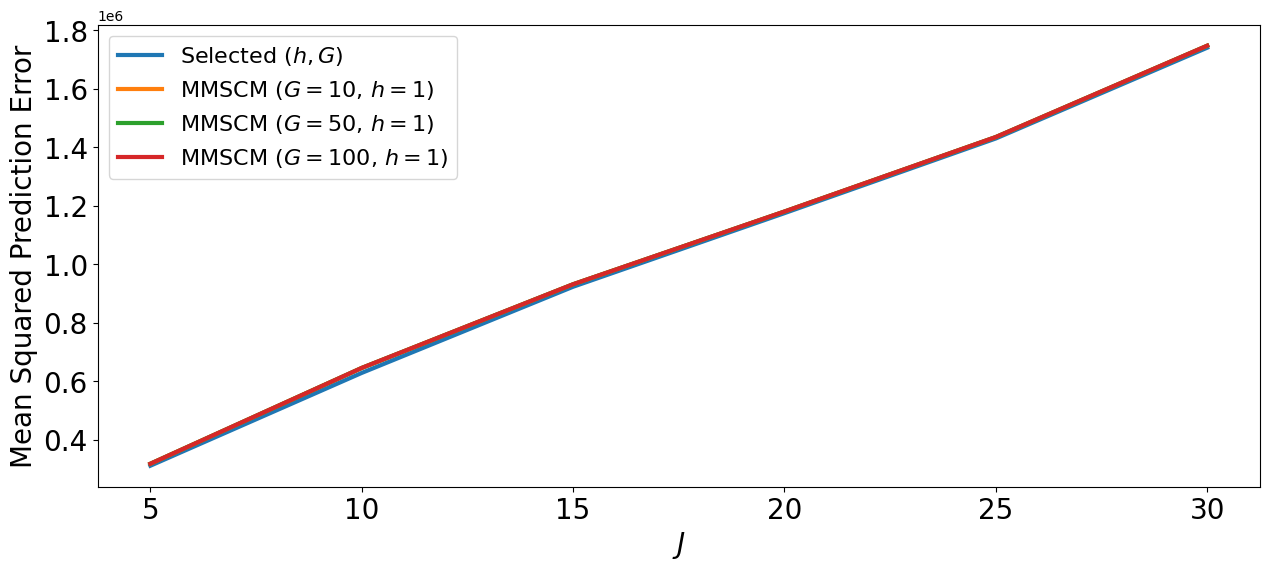

G   2    3    5    100
J                     
5     1    4    0   95
10    0    5    2   93
15    1    0    0   99
20    0    1    0   99
25    0    0    1   99
30    1    1    1   97
h   0.25  0.50  1.00  2.00  4.00
J                               
5      6    11    46    16    21
10     2     9    46     9    34
15     5     7    60     9    19
20     1     2    79     5    13
25     1     8    62     6    23
30     1     3    79     7    10


In [7]:
plt.figure(figsize=(15, 6))

plt.plot(SET_UNITS_TUNING, np.mean(np.array(tuning_selected_mse), axis=1), label="Selected $(h, G)$", linewidth=3)
plt.plot(SET_UNITS_TUNING, np.mean(np.array(tuning_fixed_g10_mse), axis=1), label="MMSCM ($G=10$, $h=1$)", linewidth=3)
plt.plot(SET_UNITS_TUNING, np.mean(np.array(tuning_fixed_g50_mse), axis=1), label="MMSCM ($G=50$, $h=1$)", linewidth=3)
plt.plot(SET_UNITS_TUNING, np.mean(np.array(tuning_fixed_g100_mse), axis=1), label="MMSCM ($G=100$, $h=1$)", linewidth=3)

plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel("Mean Squared Prediction Error", fontsize=20)
plt.xlabel("$J$", fontsize=20)
plt.legend(fontsize=16)
plt.show()

selection_df = pd.DataFrame(selection_records)
print(selection_df.groupby("J")["G"].value_counts().unstack(fill_value=0))
print(selection_df.groupby("J")["h"].value_counts().unstack(fill_value=0))


## 2. Loss-function comparison

In [7]:
np.random.seed(1)

NUM_TRIALS_LOSS = 100
SET_UNITS_LOSS = [5 * i for i in range(1, 7)]
LOSS_G = 10
LOSS_H = 1.0

loss_diag_mse = []
loss_full_gmm_mse = []
loss_l1_mse = []

for num_untreatment_units in SET_UNITS_LOSS:
    print("loss, J =", num_untreatment_units)
    diag_temp = []
    full_temp = []
    l1_temp = []

    for trial in range(NUM_TRIALS_LOSS):
        print("trial", trial)
        data = simulate_panel(
            num_untreatment_units=num_untreatment_units,
            total_period=TOTAL_PERIOD,
            intervention=INTERVENTION,
            dim=DIM,
            max_sample_size=MAX_SAMPLE_SIZE,
            treatment_effect=TRUE_TREATMENT_EFFECT,
        )

        model_diag = MMSCM(
            data,
            "MMSCM",
            TARGET_VAR,
            TARGET_UNIT,
            TARGET_VAL,
            TARGET_YEAR_VAR,
            TARGET_YEAR,
            poly=LOSS_G,
            h=LOSS_H,
            loss="diag_gmm",
        )
        model_diag.train_param()
        model_diag.predict(bias=True)
        diag_temp.append(mse_effect_error(model_diag, TRUE_TREATMENT_EFFECT, TARGET_YEAR))

        model_full = MMSCM(
            data,
            "MMSCM",
            TARGET_VAR,
            TARGET_UNIT,
            TARGET_VAL,
            TARGET_YEAR_VAR,
            TARGET_YEAR,
            poly=LOSS_G,
            h=LOSS_H,
            loss="full_gmm",
        )
        model_full.train_param()
        model_full.predict(bias=True)
        full_temp.append(mse_effect_error(model_full, TRUE_TREATMENT_EFFECT, TARGET_YEAR))

        model_l1 = MMSCM(
            data,
            "MMSCM",
            TARGET_VAR,
            TARGET_UNIT,
            TARGET_VAL,
            TARGET_YEAR_VAR,
            TARGET_YEAR,
            poly=LOSS_G,
            h=LOSS_H,
            loss="l1",
        )
        model_l1.train_param()
        model_l1.predict(bias=True)
        l1_temp.append(mse_effect_error(model_l1, TRUE_TREATMENT_EFFECT, TARGET_YEAR))

    loss_diag_mse.append(diag_temp)
    loss_full_gmm_mse.append(full_temp)
    loss_l1_mse.append(l1_temp)


loss, J = 5
trial 0
trial 1
trial 2


KeyboardInterrupt: 

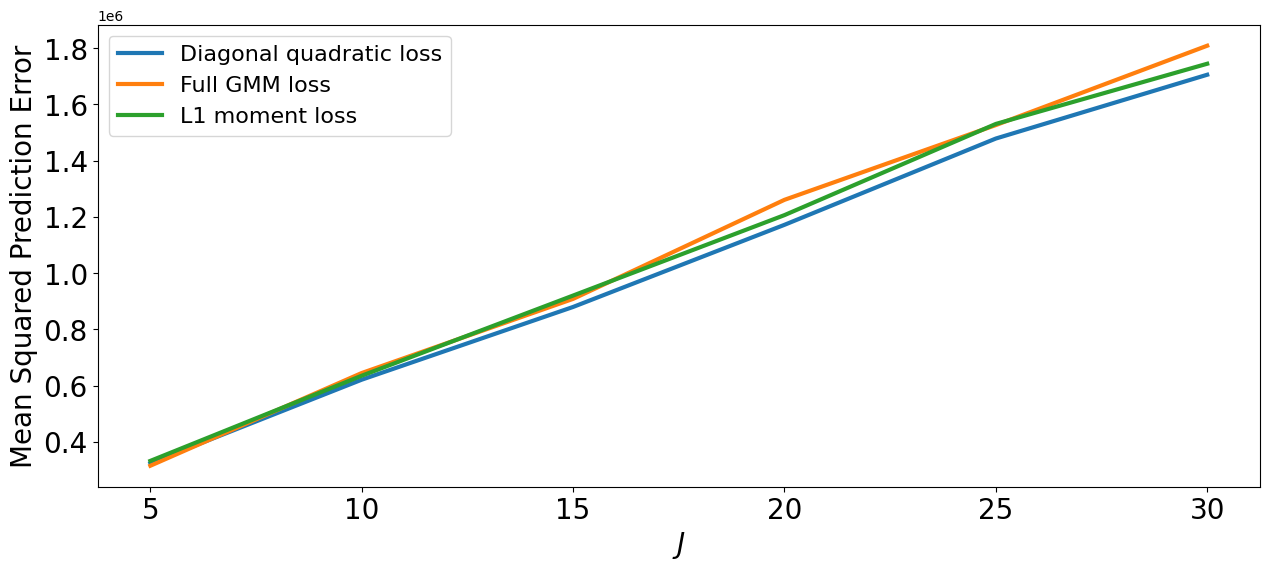

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(SET_UNITS_LOSS, np.mean(np.array(loss_diag_mse), axis=1), label="Diagonal quadratic loss", linewidth=3)
plt.plot(SET_UNITS_LOSS, np.mean(np.array(loss_full_gmm_mse), axis=1), label="Full GMM loss", linewidth=3)
plt.plot(SET_UNITS_LOSS, np.mean(np.array(loss_l1_mse), axis=1), label="L1 moment loss", linewidth=3)

plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel("Mean Squared Prediction Error", fontsize=20)
plt.xlabel("$J$", fontsize=20)
plt.legend(fontsize=16)
plt.show()


## 3. Simulation-based interval comparison with SCPI

In [18]:
def conformal_effect_interval(method_name, data, target_var, target_unit, target_val, target_year_var, target_year, split_num=100, poly=10, h=None, loss="diag_gmm"):
    if method_name == "MMSCM":
        model = MMSCM(data, method_name, target_var, target_unit, target_val, target_year_var, target_year, poly=poly, h=h, loss=loss)
    else:
        model = MMSCM(data, method_name, target_var, target_unit, target_val, target_year_var, target_year)

    model.train_param()
    model.predict(bias=False)
    treatment_effect_list = treatment_effect_path(model, target_year)

    range_interval_list = []
    for treatment_effect_temp in treatment_effect_list:
        treatment_effect_min = treatment_effect_temp - 2 * treatment_effect_temp
        treatment_effect_max = treatment_effect_temp + 2 * treatment_effect_temp
        range_interval_list_temp = np.linspace(treatment_effect_min, treatment_effect_max, split_num)
        range_interval_list.append(range_interval_list_temp)

    range_interval_list = np.array(range_interval_list).T
    interval = model.conformal_inference(range_interval_list)

    if len(interval) == 0:
        interval = np.atleast_2d(treatment_effect_list)
    else:
        interval = np.atleast_2d(interval)

    lower = np.min(interval, axis=0)
    upper = np.max(interval, axis=0)
    lower, upper = sanitize_bounds(lower, upper)
    return treatment_effect_list, lower, upper


def interval_metrics(lower, upper, true_effect):
    lower = np.array(lower, dtype=float).reshape(-1)
    upper = np.array(upper, dtype=float).reshape(-1)
    covered = (lower <= true_effect) & (true_effect <= upper)
    marginal_coverage = np.mean(covered)
    joint_coverage = float(np.all(covered))
    avg_width = np.mean(upper - lower)
    return marginal_coverage, joint_coverage, avg_width


In [22]:
np.random.seed(2)

INTERVAL_TOTAL_PERIOD = 50
INTERVAL_INTERVENTION = 30
INTERVAL_TARGET_YEAR = INTERVAL_INTERVENTION
NUM_TRIALS_INTERVAL = 20
SET_UNITS_INTERVAL = [10, 15, 20]
SPLIT_NUM_INTERVAL = 50
SCPI_SIMS = 200

interval_summary_rows = []

for num_untreatment_units in SET_UNITS_INTERVAL:
    print("intervals, J =", num_untreatment_units)
    for trial in range(NUM_TRIALS_INTERVAL):
        print("trial", trial)
        data = simulate_panel(
            num_untreatment_units=num_untreatment_units,
            total_period=INTERVAL_TOTAL_PERIOD,
            intervention=INTERVAL_INTERVENTION,
            dim=DIM,
            max_sample_size=MAX_SAMPLE_SIZE,
            treatment_effect=TRUE_TREATMENT_EFFECT,
        )

        for method_name, method_kwargs in [
            ("MMSCM", {"poly": 10, "h": 1.0, "loss": "diag_gmm"}),
            ("Abadie", {}),
            ("DiSCo", {}),
        ]:
            print(method_name)
            estimate, lower, upper = conformal_effect_interval(
                method_name,
                data,
                target_var=TARGET_VAR,
                target_unit=TARGET_UNIT,
                target_val=TARGET_VAL,
                target_year_var=TARGET_YEAR_VAR,
                target_year=INTERVAL_TARGET_YEAR,
                split_num=SPLIT_NUM_INTERVAL,
                **method_kwargs,
            )
            marginal_coverage, joint_coverage, avg_width = interval_metrics(lower, upper, TRUE_TREATMENT_EFFECT)
            interval_summary_rows.append({
                "J": num_untreatment_units,
                "trial": trial,
                "method": f"{method_name} conformal",
                "marginal_coverage": marginal_coverage,
                "joint_coverage": joint_coverage,
                "avg_width": avg_width,
            })

        for method_label, w_constr in [("SCPI (simplex)", {"name": "simplex"}), ("SCPI (ridge)", {"name": "ridge"})]:
            print(method_label)
            scpi_res = scpi_effect_interval(
                data,
                source_time_var=TARGET_YEAR_VAR,
                source_unit_var=TARGET_VAR,
                source_outcome_var=TARGET_VAL,
                target_unit=TARGET_UNIT,
                target_year=INTERVAL_TARGET_YEAR,
                w_constr=w_constr,
                sims=SCPI_SIMS,
            )
            if scpi_res is not None:
                estimate, lower, upper = scpi_res
                marginal_coverage, joint_coverage, avg_width = interval_metrics(lower, upper, TRUE_TREATMENT_EFFECT)
                interval_summary_rows.append({
                    "J": num_untreatment_units,
                    "trial": trial,
                    "method": method_label,
                    "marginal_coverage": marginal_coverage,
                    "joint_coverage": joint_coverage,
                    "avg_width": avg_width,
                })


intervals, J = 10
trial 0
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI (ridge)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
trial 1 iterations completed (100%)
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations comp

SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 10
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations c

SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
trial 19iterations completed (100%)
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations c

Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
trial 8 iterations completed (100%)
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To ch


terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 17
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations co

iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 6
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------

Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)
iterations completed (50%)
iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)
SCPI (ridge)ations completed (100%)
-----------------------------------------------
Estimating Weights...
SCPI interval estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 16
MMSCM
Abadie
DiSCo
SCPI (simplex)
-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%

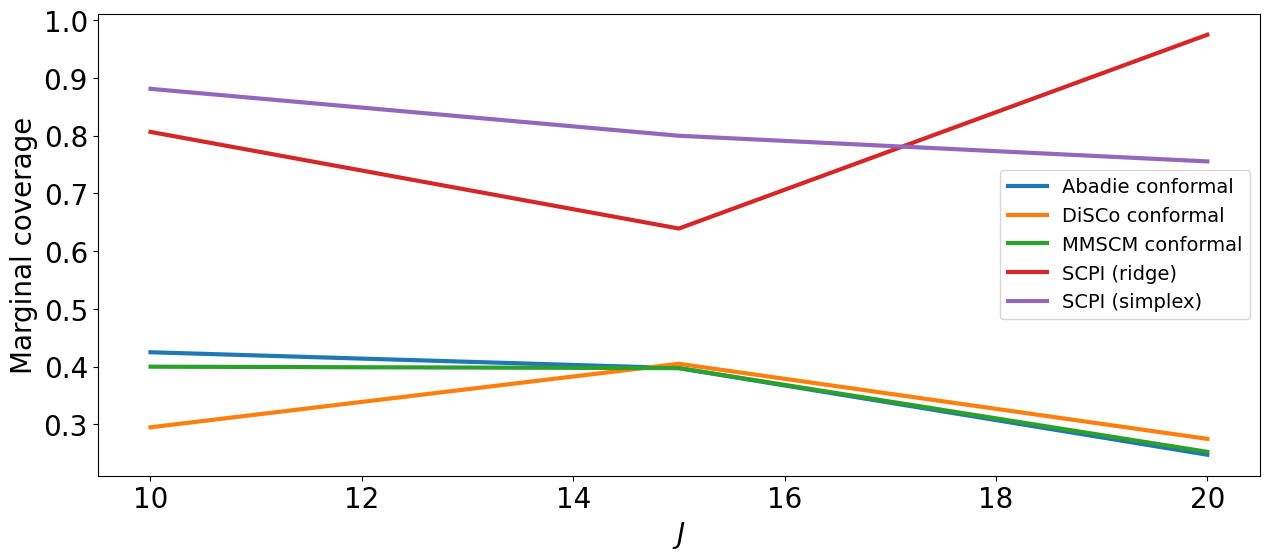

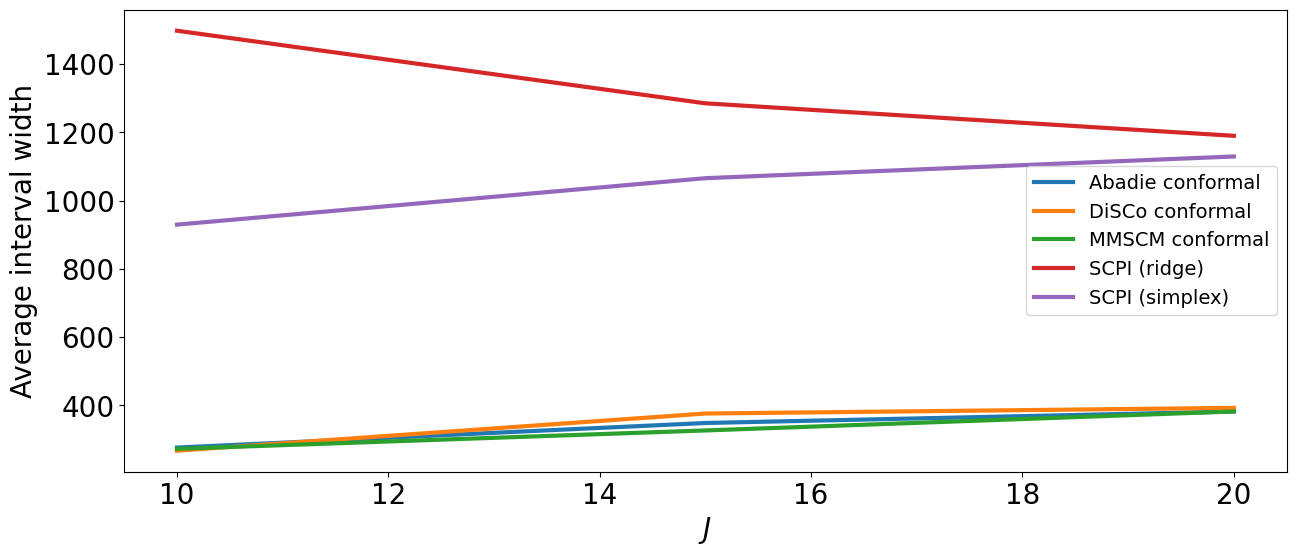

method  Abadie conformal  DiSCo conformal  MMSCM conformal  SCPI (ridge)  \
J                                                                          
10                0.4250            0.295           0.4000      0.806667   
15                0.3975            0.405           0.3975      0.639286   
20                0.2475            0.275           0.2525      0.975000   

method  SCPI (simplex)  
J                       
10            0.881250  
15            0.800000  
20            0.755556  
method  Abadie conformal  DiSCo conformal  MMSCM conformal  SCPI (ridge)  \
J                                                                          
10            276.726807       267.483115       272.990436   1497.940608   
15            348.711300       376.461993       326.881782   1285.247723   
20            382.212316       393.007113       382.617036   1190.085399   

method  SCPI (simplex)  
J                       
10          929.886699  
15         1065.911032  
20         11

In [23]:
interval_summary = pd.DataFrame(interval_summary_rows)

coverage_table = interval_summary.groupby(["J", "method"])["marginal_coverage"].mean().unstack()
width_table = interval_summary.groupby(["J", "method"])["avg_width"].mean().unstack()

plt.figure(figsize=(15, 6))
for method_name in coverage_table.columns:
    plt.plot(coverage_table.index, coverage_table[method_name].values, label=method_name, linewidth=3)
plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel("Marginal coverage", fontsize=20)
plt.xlabel("$J$", fontsize=20)
plt.legend(fontsize=14)
plt.show()

plt.figure(figsize=(15, 6))
for method_name in width_table.columns:
    plt.plot(width_table.index, width_table[method_name].values, label=method_name, linewidth=3)
plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel("Average interval width", fontsize=20)
plt.xlabel("$J$", fontsize=20)
plt.legend(fontsize=14)
plt.show()

print(coverage_table)
print(width_table)
